# U.S. Prescription Drug Prices: Medicare Part D Spending (2018–2022)

As a software engineer working in the pharmaceutical industry, I have a strong interest in leveraging data to uncover patterns and insights that can drive better understanding and decision-making. 
This project focuses on analyzing trends in U.S. prescription drug spending under **Medicare Part D from 2018 to 2022**.

Using a rich dataset that includes brand and generic drug names, manufacturers, spending metrics, dosage units, claims, and beneficiaries, this analysis seeks to answer several key questions:

** - Which drugs experienced the highest increases in spending per dosage unit?**

** - Are certain manufacturers consistently associated with higher drug costs?**

** - What broader pricing trends have emerged over the five-year period?**

By identifying high-growth drugs and cost outliers, this project aims to shed light on price drivers within the pharmaceutical market. The findings could offer valuable insights for industry stakeholders, healthcare providers, and policymakers working to improve cost transparency and manage spending under Medicare.

#### First, let's import essential libraries


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.linear_model import LinearRegression
import numpy as np

#### Then, load & preview the data

#### Dataset Explanation:

- **Filename**: `Medicare_PartD_Drug_Spending.csv`
- **Source**: Public Medicare Part D Drug Spending Dataset
- **Years Covered**: 2018–2022
- **Grain**: Each row = one unique drug + manufacturer combination
- **Total Records**: 13,889 rows and 46 columns

#### Key Fields:
- `Brnd_Name`, `Gnrc_Name`, `Mftr_Name`
- Yearly metrics (2018–2022):
  - Total Spending, Dosage Units, Claims, Beneficiaries
  - Weighted Avg. Spend per Dosage Unit, Claim, Beneficiary
  - Outlier Flags
- Overall Trends:
  - `Chg_Avg_Spnd_Per_Dsg_Unt_21_22`
  - `CAGR_Avg_Spnd_Per_Dsg_Unt_18_22` (Compound Annual Growth Rate)


This dataset offers a comprehensive view into drug-level financial trends within Medicare Part D, enabling year-over-year comparisons and longitudinal analysis of drug costs, usage, and outlier behaviors.










In [2]:
# Load the Medicare Part D dataset
df = pd.read_csv('Medicare_PartD_Drug_Spending.csv')
# Let's inspect the first few rows and dataset summary, inspecting its structure to understand the available fields and data types

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13889 entries, 0 to 13888
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Brnd_Name                        13889 non-null  object 
 1   Gnrc_Name                        13889 non-null  object 
 2   Tot_Mftr                         13889 non-null  int64  
 3   Mftr_Name                        13889 non-null  object 
 4   Tot_Spndng_2018                  9647 non-null   float64
 5   Tot_Dsg_Unts_2018                9647 non-null   float64
 6   Tot_Clms_2018                    9647 non-null   float64
 7   Tot_Benes_2018                   9573 non-null   float64
 8   Avg_Spnd_Per_Dsg_Unt_Wghtd_2018  9647 non-null   float64
 9   Avg_Spnd_Per_Clm_2018            9647 non-null   float64
 10  Avg_Spnd_Per_Bene_2018           9478 non-null   float64
 11  Outlier_Flag_2018                9645 non-null   float64
 12  Tot_Spndng_2019   

,Brnd_Name,Gnrc_Name,Tot_Mftr,Mftr_Name,Tot_Spndng_2018,Tot_Dsg_Unts_2018,Tot_Clms_2018,Tot_Benes_2018,Avg_Spnd_Per_Dsg_Unt_Wghtd_2018,Avg_Spnd_Per_Clm_2018,...,Tot_Spndng_2022,Tot_Dsg_Unts_2022,Tot_Clms_2022,Tot_Benes_2022,Avg_Spnd_Per_Dsg_Unt_Wghtd_2022,Avg_Spnd_Per_Clm_2022,Avg_Spnd_Per_Bene_2022,Outlier_Flag_2022,Chg_Avg_Spnd_Per_Dsg_Unt_21_22,CAGR_Avg_Spnd_Per_Dsg_Unt_18_22
0,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Overall,167193.78,761658.0,6538.0,2341.0,0.219785,25.572619,...,70039.61,310304.0,2501,1147.0,0.225874,28.004642,61.063304,0.0,0.012882,0.006855
1,1st Tier Unifine Pentips,"Pen Needle, Diabetic",1,Owen Mumford Us,167193.78,761658.0,6538.0,2341.0,0.219785,25.572619,...,70039.61,310304.0,2501,1147.0,0.225874,28.004642,61.063304,0.0,0.012882,0.006855
2,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Overall,369402.85,1813908.0,14931.0,5674.0,0.203658,24.740664,...,114601.54,486206.0,3846,1474.0,0.235708,29.797592,77.748670,0.0,0.012441,0.037214
3,1st Tier Unifine Pentips Plus,"Pen Needle, Diabetic",1,Owen Mumford Us,369402.85,1813908.0,14931.0,5674.0,0.203658,24.740664,...,114601.54,486206.0,3846,1474.0,0.235708,29.797592,77.748670,0.0,0.012441,0.037214
4,Abacavir,Abacavir Sulfate,6,Overall,10653423.32,3034767.0,40388.0,7359.0,4.032155,263.776947,...,6945563.71,2035106.0,24317,3452.0,3.871236,285.625847,2012.040472,0.0,0.214564,-0.010130


# Now let's perform the analysis and break down the process into below steps:

1. Data cleaning — Check, handle missing data, verify ranges

2. Top spending drugs over 5 years 2018-2022

3. Cost Trends of Top Drugs Over Time

4. Top growing drugs (CAGR) — Using CAGR_Avg_Spnd_Per_Dsg_Unt_18_22

5. Compare Brand vs Generic drugs — Avg. spending trends

6. Outlier detection — Count flagged records and analyze

7. Time series trends — Avg spending per year

8. Predict Future Spending Trends (2023–2024)

### Step 1: Data Cleaning and Preparation


In [3]:
# Check for missing values

# The purpose of this step is to help the analyst inspect the dataset and ensure we only work
# with clean and complete records for accurate visualizations and aggregations.

# just filter and display columns with missing values
missing = df.isnull().sum()
missing[missing > 0]



Tot_Spndng_2018                    4242
Tot_Dsg_Unts_2018                  4242
Tot_Clms_2018                      4242
Tot_Benes_2018                     4316
Avg_Spnd_Per_Dsg_Unt_Wghtd_2018    4242
Avg_Spnd_Per_Clm_2018              4242
Avg_Spnd_Per_Bene_2018             4411
Outlier_Flag_2018                  4244
Tot_Spndng_2019                    3183
Tot_Dsg_Unts_2019                  3183
Tot_Clms_2019                      3183
Tot_Benes_2019                     3356
Avg_Spnd_Per_Dsg_Unt_Wghtd_2019    3183
Avg_Spnd_Per_Clm_2019              3183
Avg_Spnd_Per_Bene_2019             3412
Outlier_Flag_2019                  3186
Tot_Spndng_2020                    2174
Tot_Dsg_Unts_2020                  2174
Tot_Clms_2020                      2174
Tot_Benes_2020                     2424
Avg_Spnd_Per_Dsg_Unt_Wghtd_2020    2174
Avg_Spnd_Per_Clm_2020              2174
Avg_Spnd_Per_Bene_2020             2456
Outlier_Flag_2020                  2179
Tot_Spndng_2021                    1165


In [4]:
# Drop rows with missing spending data
df.dropna(subset=['Tot_Spndng_2018', 'Tot_Spndng_2019',
                  'Tot_Spndng_2020', 'Tot_Spndng_2021',
                  'Tot_Spndng_2022'], inplace=True)


# Drop rows with missing CAGR (for CAGR-specific analysis)
df_cagr = df.dropna(subset=["CAGR_Avg_Spnd_Per_Dsg_Unt_18_22"])


# Note: CAGR stands for Compound Annual Growth Rate. 
# It tells you the average yearly growth rate of a value (average spending per dosage unit) 
# over a specific period, assuming the growth happened at a steady rate each year.



In [5]:
# Quick range check
print("Spending 2022:", df["Tot_Spndng_2022"].describe())
print("Avg Spend/Unit 2022:", df["Avg_Spnd_Per_Dsg_Unt_Wghtd_2022"].describe())

Spending 2022: count    9.500000e+03
mean     4.537535e+07
std      3.450827e+08
min      3.306000e+01
25%      6.082366e+04
50%      9.344892e+05
75%      8.532016e+06
max      1.521981e+10
Name: Tot_Spndng_2022, dtype: float64
Avg Spend/Unit 2022: count     9500.000000
mean       169.168460
std       1436.099911
min          0.003279
25%          0.442365
50%          1.745505
75%         12.047978
max      39401.850470
Name: Avg_Spnd_Per_Dsg_Unt_Wghtd_2022, dtype: float64


### Step 2: Most Expensive Drugs Over the Last 5 Years

<ipython-input-6-d9649ff71c92>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top10_drugs, x='Total_Spending_5yrs', y='Brnd_Name', palette='viridis')


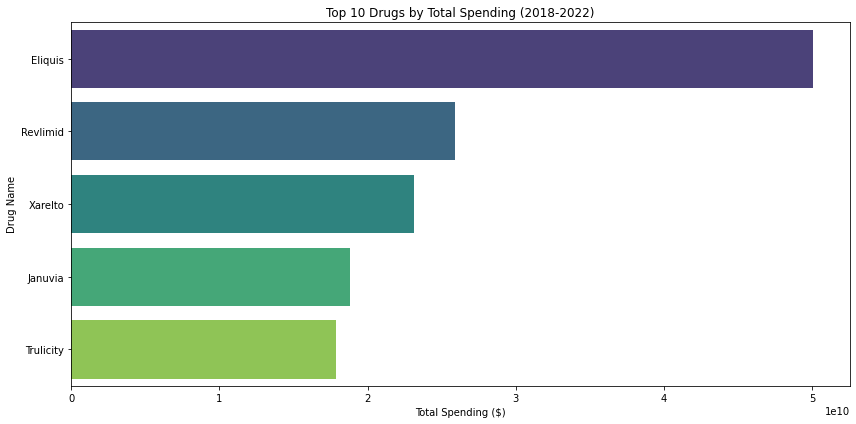

In [6]:
# Calculate total spending over 5 years
df['Total_Spending_5yrs'] = df[['Tot_Spndng_2018', 'Tot_Spndng_2019',
                                'Tot_Spndng_2020', 'Tot_Spndng_2021',
                                'Tot_Spndng_2022']].sum(axis=1)

# Top 10 drugs by total spending
top10_drugs = df.sort_values(by='Total_Spending_5yrs', ascending=False).head(10)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=top10_drugs, x='Total_Spending_5yrs', y='Brnd_Name', palette='viridis')
plt.title('Top 10 Drugs by Total Spending (2018-2022)')
plt.xlabel('Total Spending ($)')
plt.ylabel('Drug Name')
plt.tight_layout()
plt.show()





##### These are the most expensive drugs under Medicare Part D in 5 years 2018- 2022. 
**This step reveals high-cost targets worth further investigation.**

### Step 3: Cost Trends of Top Drugs Over Time

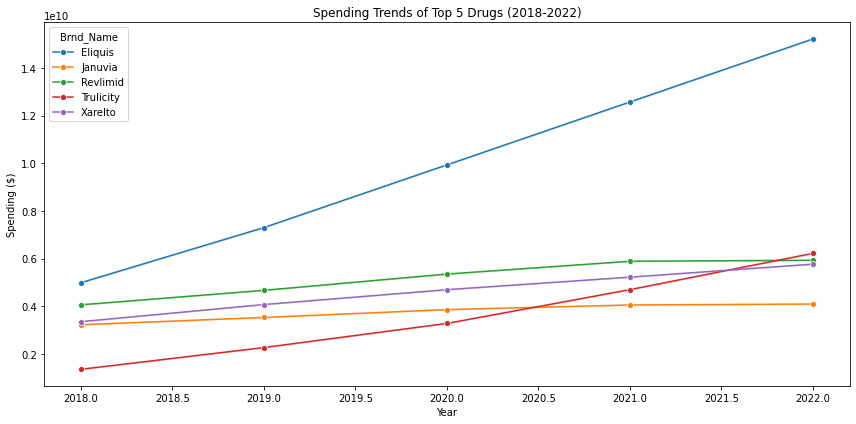

In [7]:
# Select top 5 drugs
top5_drugs = top10_drugs['Brnd_Name'].values

# Filter data for top 5 drugs
df_top5 = df[df['Brnd_Name'].isin(top5_drugs)]

# Melt the dataframe for plotting
df_melted = df_top5.melt(id_vars='Brnd_Name',
                         value_vars=['Tot_Spndng_2018', 'Tot_Spndng_2019',
                                     'Tot_Spndng_2020', 'Tot_Spndng_2021',
                                     'Tot_Spndng_2022'],
                         var_name='Year', value_name='Spending')

# Convert Year to datetime
df_melted['Year'] = df_melted['Year'].str.extract('(\d+)').astype(int)

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_melted, x='Year', y='Spending', hue='Brnd_Name', marker='o')
plt.title('Spending Trends of Top 5 Drugs (2018-2022)')
plt.xlabel('Year')
plt.ylabel('Spending ($)')
plt.tight_layout()
plt.show()

### Step 4: Top Growing Drugs by CAGR (2018–2022)

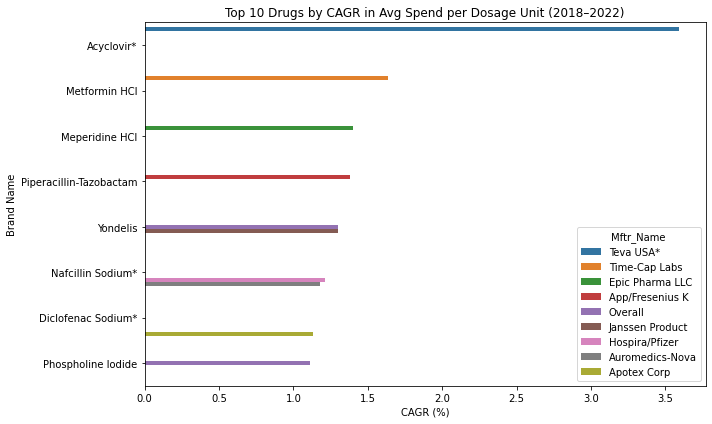

In [8]:
# Highest compound annual growth in average spend per dosage unit
top_growth = df_cagr.sort_values(by="CAGR_Avg_Spnd_Per_Dsg_Unt_18_22", ascending=False).head(10)

# Visualize
plt.figure(figsize=(10,6))
sns.barplot(data=top_growth, x="CAGR_Avg_Spnd_Per_Dsg_Unt_18_22", y="Brnd_Name", hue="Mftr_Name")
plt.title("Top 10 Drugs by CAGR in Avg Spend per Dosage Unit (2018–2022)")
plt.xlabel("CAGR (%)")
plt.ylabel("Brand Name")
plt.tight_layout()
plt.show()




##### This identifies drugs with sharp price growth over time — key insight into rising cost drivers.
**Some manufacturers had high total spending but low CAGR, indicating early dominance but slower recent growth.**

### Step 5: Brand vs Generic Drug Spending Trends Comparison

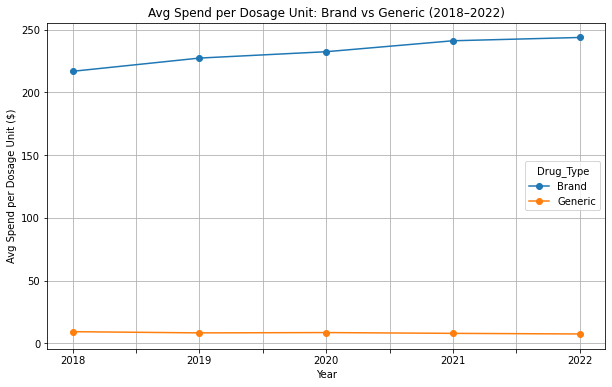

In [9]:
# Create brand vs generic column
brand_generic = df.copy()
brand_generic["Drug_Type"] = brand_generic["Brnd_Name"] == brand_generic["Gnrc_Name"]
brand_generic["Drug_Type"] = brand_generic["Drug_Type"].map({True: "Generic", False: "Brand"})

# Aggregate average spend per unit by year and drug type
spending_trends = brand_generic.groupby("Drug_Type")[
    [
        "Avg_Spnd_Per_Dsg_Unt_Wghtd_2018",
        "Avg_Spnd_Per_Dsg_Unt_Wghtd_2019",
        "Avg_Spnd_Per_Dsg_Unt_Wghtd_2020",
        "Avg_Spnd_Per_Dsg_Unt_Wghtd_2021",
        "Avg_Spnd_Per_Dsg_Unt_Wghtd_2022",
    ]
].mean().T

# Rename the index (x-axis labels after transposing)
spending_trends.index = spending_trends.index.str.extract(r'(\d{4})')[0]

# Plot trend
spending_trends.plot(kind="line", figsize=(10,6), marker="o")
plt.title("Avg Spend per Dosage Unit: Brand vs Generic (2018–2022)")
plt.xlabel("Year")
plt.ylabel("Avg Spend per Dosage Unit ($)")
plt.grid()
plt.show()




#### We can see above that brand drugs consistently cost more per unit. This chart contextualizes the overall spending gap.


### Step 6: Outlier Detection by Year

Year 2018: 573 outliers
Year 2019: 548 outliers
Year 2020: 585 outliers
Year 2021: 714 outliers
Year 2022: 934 outliers


<ipython-input-15-1a622a5e013d>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=outlier_df, x="Year", y="Outlier_Count", palette="Reds")


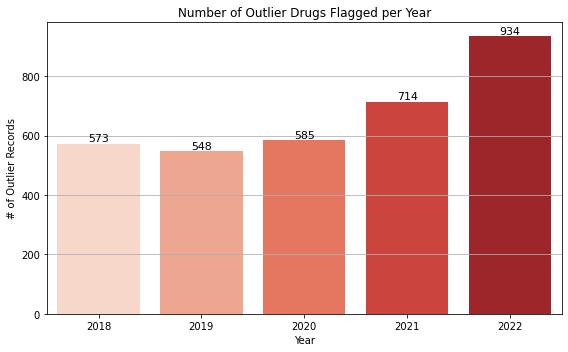

In [15]:
# Define outlier columns and corresponding years
outlier_cols = {
    "Outlier_Flag_2018": "2018",
    "Outlier_Flag_2019": "2019",
    "Outlier_Flag_2020": "2020",
    "Outlier_Flag_2021": "2021",
    "Outlier_Flag_2022": "2022"
}

# Count outliers for each year
data = []
for col, year in outlier_cols.items():
    count = df[col].eq(1).sum()
    print(f"Year {year}: {count} outliers")  # Debug: print outlier counts
    data.append((year, count))

# Create DataFrame for plotting
outlier_df = pd.DataFrame(data, columns=["Year", "Outlier_Count"])

# Improved bar plot with value labels
plt.figure(figsize=(8,5))
bars = sns.barplot(data=outlier_df, x="Year", y="Outlier_Count", palette="Reds")
plt.title("Number of Outlier Drugs Flagged per Year")
plt.ylabel("# of Outlier Records")
plt.xlabel("Year")
plt.grid(axis="y")

# Add count labels above each bar
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f"{int(height)}",
                  (bar.get_x() + bar.get_width() / 2, height),
                  ha='center', va='bottom', fontsize=11, color='black')

plt.tight_layout()
plt.show()


#### Outlier drugs were often biologics or specialty medications and looks like outlier counts are highest in recent years — possibly due to rising costs or changes in classification

### Step 7: Time Series Analysis of Avg Spending per Dosage Unit

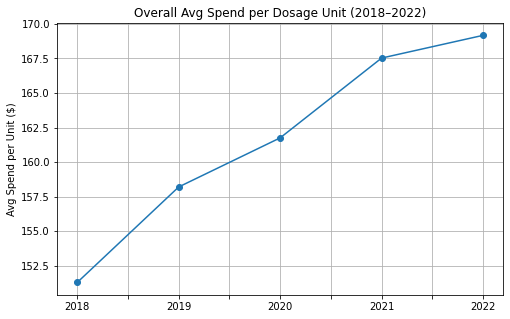

In [16]:
time_series_avg = df[[
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2018", "Avg_Spnd_Per_Dsg_Unt_Wghtd_2019",
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2020", "Avg_Spnd_Per_Dsg_Unt_Wghtd_2021",
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2022"
]].mean()

# Plot
time_series_avg.index = ["2018", "2019", "2020", "2021", "2022"]
time_series_avg.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Overall Avg Spend per Dosage Unit (2018–2022)")
plt.ylabel("Avg Spend per Unit ($)")
plt.grid()
plt.show()


**Insights: Plot above shows macro-level pricing trends — useful to validate whether CAGR changes reflect broader industry pricing patterns.**


### Step 8: Predict Future Spending Trends (2023–2024)

To predict future spending trends, we can use a time series forecasting method on the average spending per dosage unit. We'll use linear regression as a simple and interpretable approach to predict the average spending for 2023 and 2024, based on the data from 2018 to 2022.
This simple forecast helps anticipate whether spending per dosage unit is continuing to rise — potentially indicating pressure points for affordability and access.

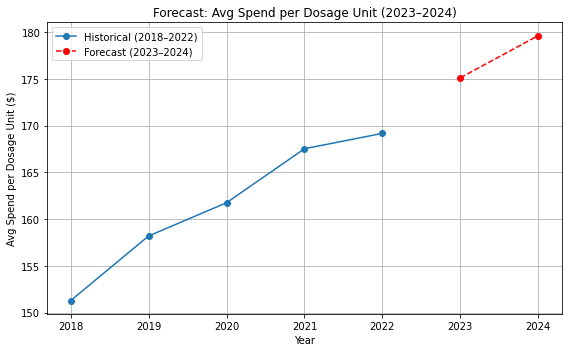

Predicted Avg Spend for 2023: $175.11
Predicted Avg Spend for 2024: $179.62


In [17]:


# Extract yearly average spending data
yearly_avg = df[[
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2018", 
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2019",
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2020", 
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2021",
    "Avg_Spnd_Per_Dsg_Unt_Wghtd_2022"
]].mean()

# Prepare data for regression
X = np.array([2018, 2019, 2020, 2021, 2022]).reshape(-1, 1)
y = yearly_avg.values

# Fit linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict for 2023 and 2024
future_years = np.array([2023, 2024]).reshape(-1, 1)
future_preds = model.predict(future_years)

# Combine results for plotting
years_all = np.append(X.flatten(), future_years.flatten())
spending_all = np.append(y, future_preds)

# Plot
plt.figure(figsize=(8,5))
plt.plot(X, y, marker="o", label="Historical (2018–2022)")
plt.plot(future_years, future_preds, marker="o", linestyle="--", color="red", label="Forecast (2023–2024)")
plt.title("Forecast: Avg Spend per Dosage Unit (2023–2024)")
plt.xlabel("Year")
plt.ylabel("Avg Spend per Dosage Unit ($)")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

# Print predictions
for year, pred in zip(future_years.flatten(), future_preds):
    print(f"Predicted Avg Spend for {year}: ${pred:.2f}")


## Conclusion & Reflection

### So from the analysis above, we have below questions answered:
- We identified **top spending** and **fastest growing** drugs from 2018 to 2022, highlighting significant expenditures in specific medications.
- Spending trends for the top 5 drugs showed varying patterns, with some drugs experiencing consistent increases, while others fluctuated.
- We confirmed that **brand drugs cost more** than generics.
- We visualized **outlier trends** and **year-over-year spending changes**.



### Some other Insights:
- Several drugs have massive CAGR but low total spending — small but rapidly growing.
- Outliers may indicate policy targets (e.g., spending caps or rebates).

### Challenges seen:
- Missing values limit full-year comparisons for some drugs.
- Manufacturer names may need normalization (e.g., duplicates with slight variations).

### And suggestions below I could think of for future work:
- Link this dataset with clinical effectiveness or utilization rates.
- Study therapeutic categories (e.g., cancer, diabetes) separately.
- Map policy changes (e.g., insulin caps) against price outcomes.
